In [91]:
import pandas as pd
import numpy as np

# Set seed for reproducibility of hidden behavioral signals
np.random.seed(88)
num_calls = 15000

# Generate timestamps over a 72-hour window in 2026
timestamps = pd.to_datetime('2026-06-01 00:00:00') + pd.to_timedelta(np.random.randint(0, 259200, num_calls), unit='s')

# Create Base Employee Call Ingestion Telemetry
departments = ['Executive Suite', 'Finance', 'IT Operations', 'Customer Success', 'Legal']
dept_pool = np.random.choice(departments, num_calls, p=[0.05, 0.15, 0.10, 0.50, 0.20])

employees = [f'emp_{i}' for i in range(1, 501)]
emp_pool = np.random.choice(employees, num_calls)

# Audio biometrics: Probability that vocal artifact matching points to AI Real-time Voice Clone Synthesis
ai_voice_prob = np.random.beta(2, 5, num_calls) * 0.4  # Base distribution skewed low

vishing_telemetry = pd.DataFrame({
    'call_id': [f'call_{i}' for i in range(num_calls)],
    'employee_id': emp_pool,
    'department_context': dept_pool,
    'timestamp': timestamps,
    'ai_voice_synthesis_prob': ai_voice_prob,
    'outbound_transfers_triggered': np.random.poisson(0.2, num_calls),
    'vishing_attack_confirmed': 0
})

# INJECT COMBINED ATTACK VECTORS (The Hidden Signals)
# Vector 1: Highly targeted AI Executive impersonation aiming for Finance/Wire transfers
finance_targets = vishing_telemetry[vishing_telemetry['department_context'] == 'Finance'].index
vishing_telemetry.loc[finance_targets, 'ai_voice_synthesis_prob'] = np.random.uniform(0.3, 0.65, len(finance_targets))

# Critical Malicious Intersection: High AI Voice probability + Outbound transfer action in sensitive departments
attack_idx_1 = vishing_telemetry[(vishing_telemetry['department_context'].isin(['Finance', 'Executive Suite'])) & 
                                  (vishing_telemetry['ai_voice_synthesis_prob'] > 0.75)].index
vishing_telemetry.loc[attack_idx_1, 'vishing_attack_confirmed'] = 1
vishing_telemetry.loc[attack_idx_1, 'outbound_transfers_triggered'] += np.random.randint(1, 3, len(attack_idx_1))

# Vector 2: Rapid IT Credentials Harvesting Spray (targeting multiple endpoints over short bursts)
it_targets = vishing_telemetry[(vishing_telemetry['department_context'] == 'IT Operations') & 
                               (vishing_telemetry['timestamp'].dt.hour.isin([14, 15, 16]))].index
vishing_telemetry.loc[it_targets, 'vishing_attack_confirmed'] = np.random.choice([0, 1], len(it_targets), p=[0.3, 0.7])
vishing_telemetry.loc[it_targets, 'ai_voice_synthesis_prob'] = np.random.uniform(0.80, 0.99, len(it_targets))

# Save Ingestion Block
vishing_telemetry.to_parquet('vishing_stream_telemetry.parquet', index=False)

# 2. HISTORICAL RISK INTELLIGENCE REGISTRY
historical_profiles = pd.DataFrame({
    'employee_id': [f'emp_{i}' for i in range(1, 501)],
    'vishing_sim_fail_rate': np.random.uniform(0.02, 0.55, 500), # Historical failure rate in internal tests
    'security_awareness_score': np.random.randint(10, 100, 500)  # Human training tier score (higher = safer)
})
historical_profiles.to_parquet('human_risk_registry.parquet', index=False)

print(f"Mothership 4.0 Live. {num_calls} voice telemetry interactions generated.")

Mothership 4.0 Live. 15000 voice telemetry interactions generated.


## The following parquet files are available
- vishing_stream_telemetry.parquet
- human_risk_registry.parquet

In [92]:
# Phase 1: Storage Optimization & Ingestion Engineering
vst = pd.read_parquet('vishing_stream_telemetry.parquet') # All columns seem relevant - otherwise columns=['example'] could be used to select cols
hrr = pd.read_parquet('human_risk_registry.parquet')

# 2. By using a L1 and L2 schema of loading memory in the cache memory, trusted people could be loaded into the quicker portion of the cache memory and others in the slower memory.
# Also, by selecting only the needed columns for both parquet files to be loaded this could save loads of memory and increase efficiency.

# print(vst.info())
# print(hrr.info())

# Phase 2: Feature Engineering & In-Memory Pipeline
# Merge of vst and hrr df's
df = pd.merge(
    vst,
    hrr,
    on='employee_id',
    how='left'
)

# Calculate a composite feature called human_vulnerability_index:
df['human_vulnerability_index'] = (
    (df['vishing_sim_fail_rate'] * df['outbound_transfers_triggered']) / (df['security_awareness_score'] + 1)
).round(6)

# Calculate a non-shifted 30-minute rolling call count
# rolling window entails that df should be sorted according to department context and timestamp
# Timestamp to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort df
df = df.sort_values(['department_context', 'timestamp'])

# Set df index to timestamp
df = df.set_index('timestamp')

# Create rolling window of 30 min and calculate rolling call count
df['call_count_30m'] = (
    df.groupby('department_context')['call_id']
      .rolling('30min')
      .count()
      .reset_index(level=0, drop=True)
      .astype(int)
)

# Phase 3
# 1. Vectorisation (don't know tbh) - This leads to memory management at it's core. The main idea would be to overload the memory as little as possible and still efficiently doing aggregations at the same time.
# 2. This process will take 200ms and if it violates our pipeline SLA, that means it is too slow. Pre-aggregation of our features and by using a combination of offline and online feature stores could be a solution.

In [93]:
# Phase 4
# Set up a chronological train/test split (80/20) using the transaction timelines.
# Reset index after feature engineering is done
df = df.reset_index()

df = df.sort_values('timestamp')

df

,timestamp,call_id,employee_id,department_context,ai_voice_synthesis_prob,outbound_transfers_triggered,vishing_attack_confirmed,vishing_sim_fail_rate,security_awareness_score,human_vulnerability_index,call_count_30m
8243,2026-06-01 00:00:34,call_3979,emp_143,Finance,0.371408,0,0,0.540032,71,0.000000,1
12046,2026-06-01 00:00:47,call_6129,emp_3,Legal,0.126043,0,0,0.182428,29,0.000000,1
0,2026-06-01 00:00:48,call_2255,emp_179,Customer Success,0.068528,0,0,0.484350,36,0.000000,1
12047,2026-06-01 00:01:50,call_7755,emp_461,Legal,0.044633,0,0,0.345791,26,0.000000,2
8244,2026-06-01 00:02:00,call_2541,emp_196,Finance,0.588123,1,0,0.219231,65,0.003322,2
...,...,...,...,...,...,...,...,...,...,...,...
10532,2026-06-03 23:58:49,call_7344,emp_137,Finance,0.369205,0,0,0.110662,19,0.000000,13
14997,2026-06-03 23:58:52,call_11600,emp_480,Legal,0.032713,0,0,0.279692,50,0.000000,22
12045,2026-06-03 23:59:01,call_5627,emp_462,IT Operations,0.139206,0,0,0.435358,72,0.000000,12
14998,2026-06-03 23:59:08,call_9977,emp_251,Legal,0.118231,0,0,0.439855,45,0.000000,22


              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2945
           1       0.91      0.18      0.30        55

    accuracy                           0.98      3000
   macro avg       0.95      0.59      0.65      3000
weighted avg       0.98      0.98      0.98      3000

[[2944    1]
 [  45   10]]


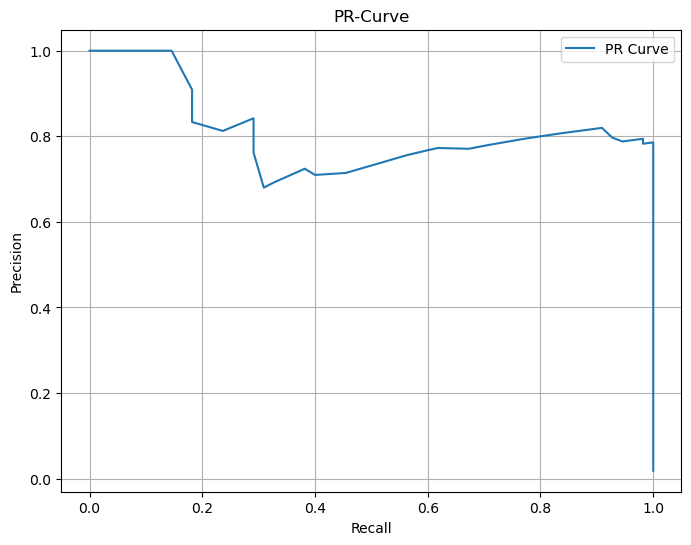

In [ ]:
# Create a time_split tactic to split data into training and testing portions - 80/20 split
time_split = df['timestamp'].quantile(0.8)

# Define columns to be used X and y
X_cols = df.drop(columns=['timestamp', 'vishing_attack_confirmed'])
y_col = df['vishing_attack_confirmed']

# Apply timesplit to training and testing data
X_train = X_cols[df['timestamp'] < time_split]
X_test = X_cols[df['timestamp'] >= time_split]
y_train = y_col[df['timestamp'] < time_split]
y_test = y_col[df['timestamp'] >= time_split]

cat_cols = [col for col in X_cols.columns if X_cols[col].dtype == 'object']
num_cols = [col for col in X_cols.columns if X_cols[col].dtype != 'object']

# import classification library tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

import matplotlib.pyplot as plt

preprocessor = ColumnTransformer(
    transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]
)

# Fit model to training data
model.fit(X_train, y_train)

# Model make predictions
y_preds = model.predict(X_test)

# Model accuracy check - not necessary
clf_score = model.score(X=X_test, y=y_test)

# Find probabilities for all predicions made
y_scores = model.predict_proba(X=X_test)[:, 1]

# Print classification report
print(classification_report(y_pred=y_preds, y_true=y_test))
print(confusion_matrix(y_pred=y_preds, y_true=y_test))

precision, recall, thresholds = precision_recall_curve(y_true=y_test, y_score=y_scores)
avg_precision = average_precision_score(y_true=y_test, y_score=y_scores)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR Curve")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. When seeing a massive discrepancy during the cross-validation score that means that a data leak should be evident somewhere in the training set. Probably with the model learning from future events. 

# Phase 5
# 1. Good question. That would depend, but if the threshold can be dynamically adjusted and the user has had an extra training, I would argue that the user with a higher training score would be less 
# prone to attacks, and dynamically adjust this decision threshold based on a user's training score. The higher the score, the higher the threshold can be to increase precision.

# Phase 6
# 1. I would use the KSI metric to detect this drift
# 2. The model makes use of SHAP, which uses feature importance to identify a specific call as good or bad (using a compounding method). This call probably fulfilled most of the requirements
# to be seen as a bad call and was blocked. 
